In [1]:
import pandas as pd

df = pd.read_csv('amazon.csv')

# 1) 통화/쉼표/퍼센트 기호 제거 후 숫자로
for col in ['discounted_price', 'actual_price']:
    df[col] = df[col].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)

# 2) rating: "|" 같은 비정상 값은 결측치로 처리
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')  # 변환 안 되는 값은 NaN으로

# 3) rating_count: 쉼표 제거 후 숫자로 (기존 결측치는 그대로 NaN 유지됨)
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False).astype(float)

In [2]:
print(df['rating'].isnull().sum())


1


In [3]:
df[df['rating'].isnull()]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,16.0,NaN,992.0,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [4]:
df['rating'].fillna(df['rating'].median(), inplace=True)  # 또는 category별 median

C:\Users\황세원\AppData\Local\Temp\ipykernel_90468\2159790195.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['rating'].fillna(df['rating'].median(), inplace=True)  # 또는 category별 median


0       4.2
1       4.0
2       3.9
3       4.2
4       4.2
       ... 
1460    4.0
1461    4.1
1462    3.6
1463    4.0
1464    4.3
Name: rating, Length: 1465, dtype: float64

In [5]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [6]:
print(df['rating'].isnull().sum())  # 0이 나와야 정상
print(df.loc[1279, 'rating'])       # NaN 아니라 중앙값으로 채워졌는지 확인

0
4.1


In [7]:
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [8]:
df_raw = pd.read_csv('amazon.csv')
print(df_raw[df_raw['product_id'].isin(['B0B94JPY2N', 'B0BQRJ3C47'])].to_dict('records'))

[{'product_id': 'B0B94JPY2N', 'product_name': 'Amazon Brand - Solimo 65W Fast Charging Braided Type C to C Data Cable | Suitable For All Supported Mobile Phones (1 Meter, Black)', 'category': 'Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables', 'discounted_price': '₹199', 'actual_price': '₹999', 'discount_percentage': '80%', 'rating': '3.0', 'rating_count': nan, 'about_product': 'USB C to C Cable: This cable has type C connector at both ends and a USB C type wall charger/adapter will be required to be used with this cable|Durable and sturdy: 1 meter long cable with 5mm thickness|65W fast charging up to 4A/ 65W|Comes with Smart Charge Auto Detect Technology|The cable supports data transfer at a speed of 480Mbps|Prevents overheating and overcharging with several built-in safeguards|Suitable for all major smartphones including OnePlus, Xiaomi, Realme, Oppo, etc.', 'user_id': 'AE7CFHY23VAJT2FI4NZKKP6GS2UQ', 'user_name': 'Pranav', 'review_id': 'RUB7U91HVZ30',

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
dtyp

In [10]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,3125.310874,5444.990635,47.691468,4.096587,18277.634812
std,6944.304394,10874.826864,21.635905,0.291574,42727.398216
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17325.000000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [11]:
df.nunique()

product_id             1351
product_name           1337
category                211
discounted_price        550
actual_price            449
discount_percentage      92
rating                   25
rating_count           1143
about_product          1293
user_id                1194
user_name              1194
review_id              1194
review_title           1194
review_content         1212
img_link               1412
product_link           1465
dtype: int64

In [12]:
dup_ids = df['product_id'][df['product_id'].duplicated(keep=False)]
df[df['product_id'].isin(dup_ids)].sort_values('product_id')[['product_id','product_name','rating','rating_count','review_id']].head(20)

,product_id,product_name,rating,rating_count,review_id
46,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,4.1,8131.0,"R2EJIN3N3L3XKI,R2JMJ8QNG66LV4,R3B46JNPC2T4E7,R..."
881,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,4.1,8131.0,"R2EJIN3N3L3XKI,R2JMJ8QNG66LV4,R3B46JNPC2T4E7,R..."
33,B008FWZGSG,Samsung Original Type C to C Cable - 3.28 Feet...,4.3,355.0,"R2Z9ENI1BK4EAB,R2JTBG4GO7WPMG,R3GKCN4UH999M8,R..."
833,B008FWZGSG,Samsung Original Type C to C Cable - 3.28 Feet...,4.3,355.0,"R2Z9ENI1BK4EAB,R2JTBG4GO7WPMG,R3GKCN4UH999M8,R..."
40,B00NH11KIK,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,4.5,107687.0,"R2AE3BN2Y58N55,R6YVRITBSRECR,R232KD83Q3MVML,R2..."
852,B00NH11KIK,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,4.5,107686.0,"R2AE3BN2Y58N55,R6YVRITBSRECR,R232KD83Q3MVML,R2..."
30,B00NH11PEY,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,4.5,74976.0,"R1C8MVU3EIX56Y,R10RUXC7JD5S4I,R1AFBZ5PYTHO1Z,R..."
802,B00NH11PEY,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,4.5,74976.0,"R1C8MVU3EIX56Y,R10RUXC7JD5S4I,R1AFBZ5PYTHO1Z,R..."
90,B0141EZMAI,"Gizga Essentials USB WiFi Adapter for PC, 150 ...",3.6,10134.0,"R3AZDEK3MQA3RA,RXF3HCCBWV0VB,R6CVYFDUXBS36,R1Q..."
1019,B0141EZMAI,"Gizga Essentials USB WiFi Adapter for PC, 150 ...",3.6,10134.0,"R3AZDEK3MQA3RA,RXF3HCCBWV0VB,R6CVYFDUXBS36,R1Q..."


In [13]:
# 중복 개수 재확인
print(df['product_id'].duplicated().sum())  # 몇 개 행이 제거 대상인지

# product_id 기준 중복 제거 (동일 상품 최신 스냅샷만 남김)
df_dedup = df.drop_duplicates(subset='product_id', keep='last').reset_index(drop=True)
print(df_dedup.shape)  # (1351, 16) 나오는지 확인

114
(1351, 16)


Matplotlib is building the font cache; this may take a moment.


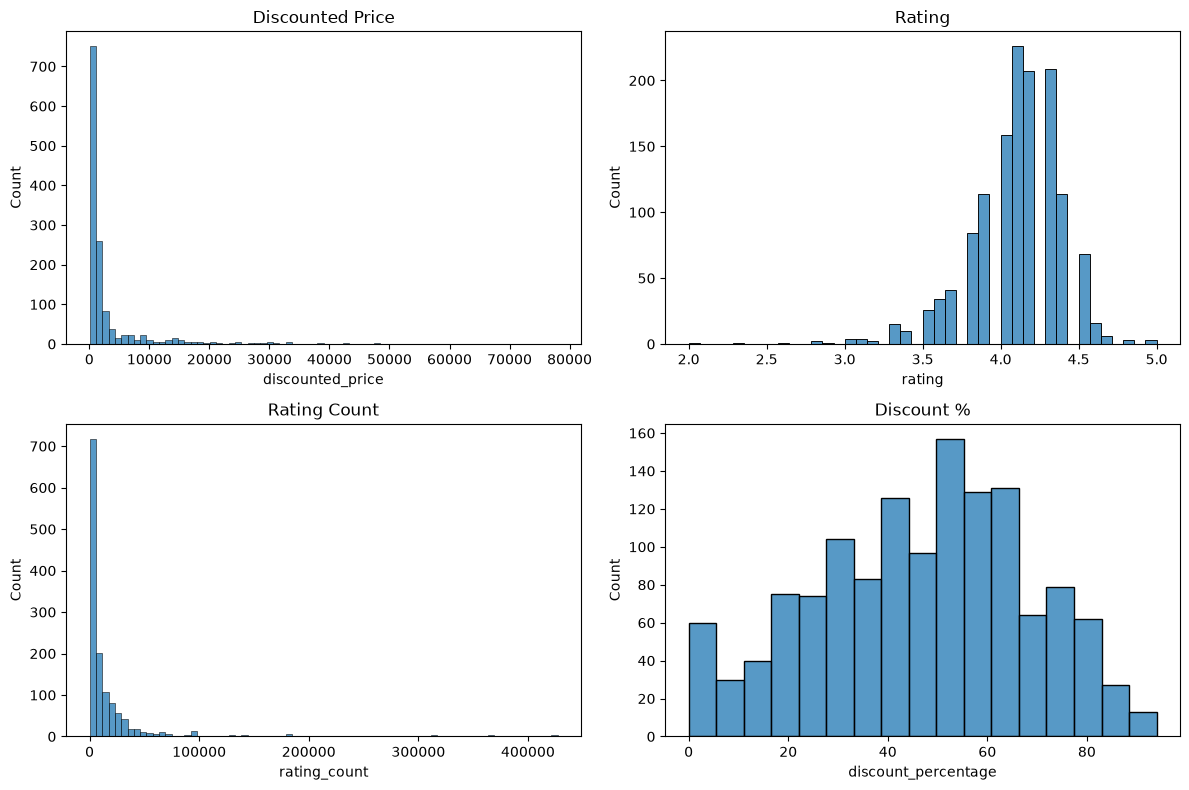

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_dedup['discounted_price'], ax=axes[0,0]).set_title('Discounted Price')
sns.histplot(df_dedup['rating'], ax=axes[0,1]).set_title('Rating')
sns.histplot(df_dedup['rating_count'], ax=axes[1,0]).set_title('Rating Count')
sns.histplot(df_dedup['discount_percentage'], ax=axes[1,1]).set_title('Discount %')
plt.tight_layout()
plt.show()

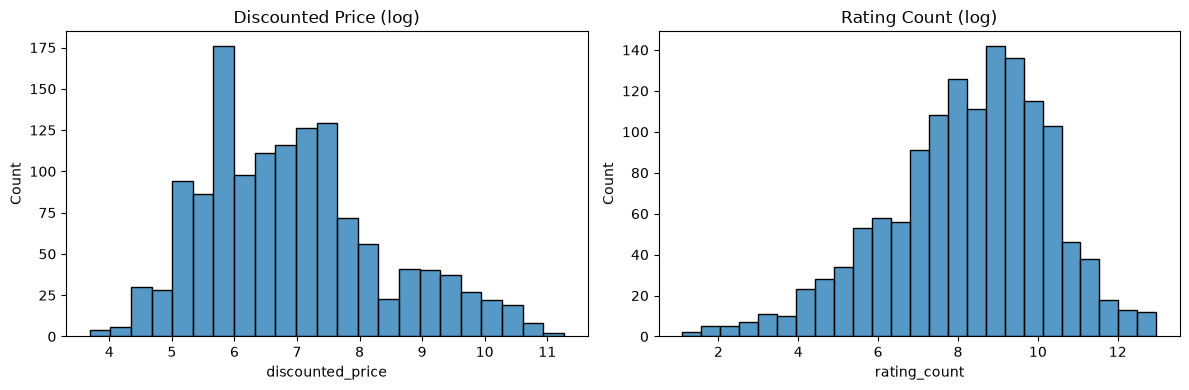

In [15]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(df_dedup['discounted_price']), ax=axes[0]).set_title('Discounted Price (log)')
sns.histplot(np.log1p(df_dedup['rating_count']), ax=axes[1]).set_title('Rating Count (log)')
plt.tight_layout()
plt.show()

In [16]:
df_dedup['main_category'] = df_dedup['category'].str.split('|').str[0]
print(df_dedup['main_category'].value_counts())

main_category
Electronics              490
Home&Kitchen             448
Computers&Accessories    375
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


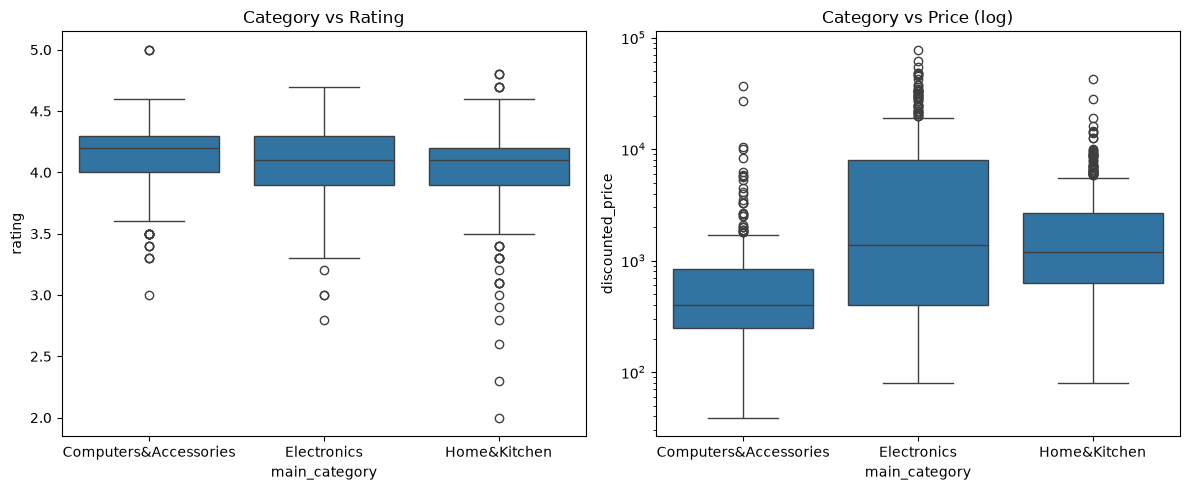

In [17]:
top3 = ['Electronics', 'Home&Kitchen', 'Computers&Accessories']
df_top3 = df_dedup[df_dedup['main_category'].isin(top3)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_top3, x='main_category', y='rating', ax=axes[0])
axes[0].set_title('Category vs Rating')

sns.boxplot(data=df_top3, x='main_category', y='discounted_price', ax=axes[1])
axes[1].set_yscale('log')  # 가격은 아까처럼 log scale로
axes[1].set_title('Category vs Price (log)')

plt.tight_layout()
plt.show()

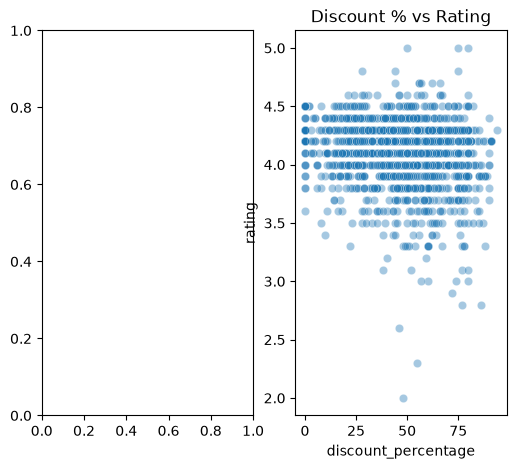

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(6, 5))
sns.scatterplot(data=df_dedup, x='discount_percentage', y='rating', alpha=0.4)
plt.title('Discount % vs Rating')
plt.show()

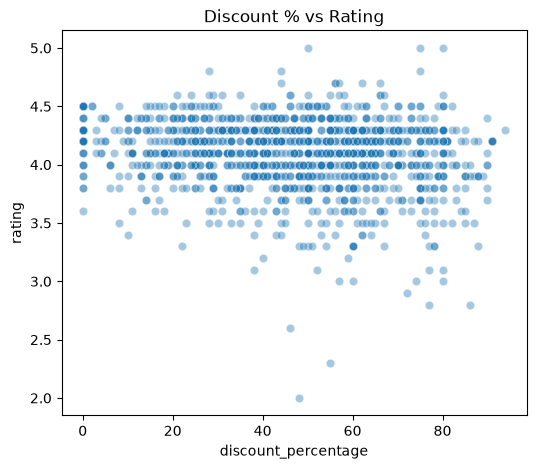

In [20]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_dedup, x='discount_percentage', y='rating', alpha=0.4)
plt.title('Discount % vs Rating')
plt.show()

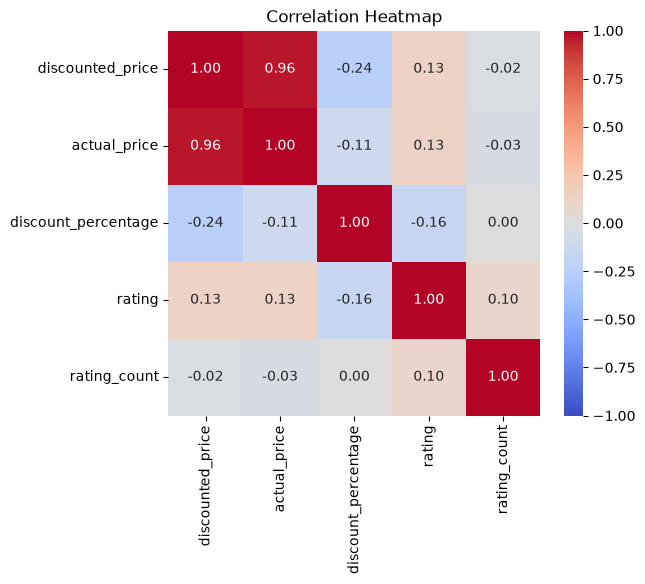

In [19]:
import numpy as np

corr_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
corr = df_dedup[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [22]:
!pip install duckdb
import duckdb

"검증된 인기 상품이에요"

평점 4.5 이상 + 리뷰 수 많은 순 → 품질과 대중성을 동시에 만족하는 상품

96개 도출, SanDisk SD카드가 20만+ 리뷰로 1위. 단, 하위권엔 리뷰 10개 미만 상품도 섞여 있어 "인기"라는 이름에 안 맞는 한계 있음 (개선 여지: rating_count > N 같은 최소 표본 조건 추가 고려)

In [23]:
query = """
SELECT product_id, product_name, rating, rating_count
FROM (
  SELECT *,
         ROW_NUMBER() OVER (
           PARTITION BY product_id 
           ORDER BY rating_count DESC
         ) AS rn
  FROM df_dedup
)
WHERE rn = 1 
  AND rating >= 4.5
ORDER BY rating_count DESC
LIMIT 100
"""

result = duckdb.sql(query).df()  # .df()로 결과를 다시 pandas DataFrame으로 변환
result


,product_id,product_name,rating,rating_count
0,B09X7DY7Q4,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,205052.0
1,B00NH11KIK,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,4.5,107686.0
2,B07G3YNLJB,Crucial BX500 240GB 3D NAND SATA 6.35 cm (2.5-...,4.5,92925.0
3,B00NH13Q8W,AmazonBasics USB 2.0 Extension Cable for Perso...,4.5,74977.0
4,B00NH11PEY,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,4.5,74976.0
...,...,...,...,...
91,B08QW937WV,Homeistic Applience™ Instant Electric Water He...,4.5,19.0
92,B0BMTZ4T1D,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,4.5,11.0
93,B09P1MFKG1,Melbon VM-905 2000-Watt Room Heater (ISI Certi...,4.6,9.0
94,B0BNDD9TN6,WANBO X1 Pro (Upgraded) | Native 1080P Full HD...,4.5,7.0


"이 카테고리에선 이게 최고예요"

대분류(Electronics, Home&Kitchen 등)별로 독립적인 평점 순위를 매겨, 사용자가 관심 있는 카테고리 안에서만 최적의 선택지를 제공

9개 대분류 각각 최대 5개씩, 총 35개 도출. Computers&Accessories에서 4.6점 상품이 5개나 동점이라 RANK가 공동 4등 처리한 것 확인. 표본이 1~2개뿐인 카테고리(Toys&Games 등)는 있는 만큼만 자연스럽게 반영됨

In [24]:
result_from_raw = duckdb.sql("""
SELECT product_id, product_name, rating, rating_count
FROM (
  SELECT *,
         ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
  FROM df
)
WHERE rn = 1 AND rating >= 4.5
ORDER BY rating_count DESC
""").df()

print(result_from_raw.shape)

(96, 4)


In [ ]:
query2 = """
SELECT product_id, product_name, main_category, rating, category_rank
FROM (
  SELECT product_id, product_name, rating,
         SPLIT_PART(category, '|', 1) AS main_category,
         RANK() OVER (
           PARTITION BY SPLIT_PART(category, '|', 1)
           ORDER BY rating DESC
         ) AS category_rank
  FROM df
)
WHERE category_rank <= 5
ORDER BY main_category, category_rank
"""

result2 = duckdb.sql(query2).df()
result2

,product_id,product_name,main_category,rating,category_rank
0,B0912WJ87V,Reffair AX30 [MAX] Portable Air Purifier for C...,Car&Motorbike,3.8,1
1,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,5.0,1
2,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories,5.0,1
3,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,5.0,1
4,B00NFD0ETQ,Logitech G402 Hyperion Fury USB Wired Gaming M...,Computers&Accessories,4.6,4
5,B01MQ2A86A,"Logitech M331 Silent Plus Wireless Mouse, 2.4G...",Computers&Accessories,4.6,4
6,B07X2L5Z8C,Logitech Pebble M350 Wireless Mouse with Bluet...,Computers&Accessories,4.6,4
7,B01J1CFO5I,Redgear MP35 Speed-Type Gaming Mousepad (Black...,Computers&Accessories,4.6,4
8,B09XXZXQC1,Xiaomi Pad 5| Qualcomm Snapdragon 860| 120Hz R...,Computers&Accessories,4.6,4
9,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Electronics,4.7,1


In [26]:
duckdb.sql("""
SELECT *, 
       ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
FROM df
WHERE product_id = 'B0B9BXKBC7'
""").df()


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,rn
0,B0B9BXKBC7,"WeCool S5 Long Selfie Stick, with Large Reinfo...",Electronics|Mobiles&Accessories|MobileAccessor...,1799.0,3999.0,55.0,4.6,245.0,"64"" Tall Cell Phone Tripods with 7 section adj...","AFPYH3UF3GB4RNX3MX46AXFM2FTQ,AGWEQHJSUA4YCG44R...","Sujili v,Paras Jain,Shailendra,supreeth achar,...","R2MI4KSWYUEMDR,R2MNYKDL2UII1M,R2C6TUBM6IVLB0,R...","Good,Good Product but Little expensive.,Happy ...","Good,Thoda sa kam stable hai, phone lagane ke ...",https://m.media-amazon.com/images/I/41fDM4QUfv...,https://www.amazon.in/WeCool-Reinforced-Functi...,1
1,B0B9BXKBC7,"WeCool S5 Long Selfie Stick, with Large Reinfo...",Electronics|Mobiles&Accessories|MobileAccessor...,1799.0,3999.0,55.0,4.6,245.0,"64"" Tall Cell Phone Tripods with 7 section adj...","AFPYH3UF3GB4RNX3MX46AXFM2FTQ,AGWEQHJSUA4YCG44R...","Sujili v,Paras Jain,Shailendra,supreeth achar,...","R2MI4KSWYUEMDR,R2MNYKDL2UII1M,R2C6TUBM6IVLB0,R...","Good,Good Product but Little expensive.,Happy ...","Good,Thoda sa kam stable hai, phone lagane ke ...",https://m.media-amazon.com/images/I/41fDM4QUfv...,https://www.amazon.in/WeCool-Reinforced-Functi...,2


In [27]:
query2_fixed = """
SELECT product_id, product_name, main_category, rating, category_rank
FROM (
  SELECT product_id, product_name, rating,
         SPLIT_PART(category, '|', 1) AS main_category,
         RANK() OVER (
           PARTITION BY SPLIT_PART(category, '|', 1)
           ORDER BY rating DESC
         ) AS category_rank
  FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
    FROM df
  )
  WHERE rn = 1
)
WHERE category_rank <= 5
ORDER BY main_category, category_rank
"""

result2_fixed = duckdb.sql(query2_fixed).df()
result2_fixed[result2_fixed['product_id'] == 'B0B9BXKBC7']  # 이제 1개만 나오는지 확인

,product_id,product_name,main_category,rating,category_rank
13,B0B9BXKBC7,"WeCool S5 Long Selfie Stick, with Large Reinfo...",Electronics,4.6,3


In [28]:
result2_fixed

,product_id,product_name,main_category,rating,category_rank
0,B0912WJ87V,Reffair AX30 [MAX] Portable Air Purifier for C...,Car&Motorbike,3.8,1
1,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,5.0,1
2,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories,5.0,1
3,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,5.0,1
4,B07X2L5Z8C,Logitech Pebble M350 Wireless Mouse with Bluet...,Computers&Accessories,4.6,4
5,B01MQ2A86A,"Logitech M331 Silent Plus Wireless Mouse, 2.4G...",Computers&Accessories,4.6,4
6,B01J1CFO5I,Redgear MP35 Speed-Type Gaming Mousepad (Black...,Computers&Accessories,4.6,4
7,B09XXZXQC1,Xiaomi Pad 5| Qualcomm Snapdragon 860| 120Hz R...,Computers&Accessories,4.6,4
8,B00NFD0ETQ,Logitech G402 Hyperion Fury USB Wired Gaming M...,Computers&Accessories,4.6,4
9,B0B23LW7NV,Spigen EZ Fit Tempered Glass Screen Protector ...,Electronics,4.7,1


In [29]:
(result2_fixed['product_id'].value_counts() > 1).sum()  # 0이 나와야 완전히 안전

np.int64(0)

"이 정도면 놓치면 손해예요"

할인율과 평점을 곱한 합성 점수로 "많이 할인하면서도 품질이 검증된" 상품만 선별

상위권은 할인율 80~94% + 평점 4.2~5.0 조합 상품들. 한쪽만 극단적으로 높은 상품(예: 할인 94%지만 평점 2점대)은 자연스럽게 하위로 밀려남 → 곱셈 방식이 "가성비"라는 개념을 의도대로 구현했음을 확인

In [30]:
query3 = """
SELECT product_id, product_name, discount_percentage, rating, value_score
FROM (
  SELECT product_id, product_name, discount_percentage, rating,
         ROUND(discount_percentage * rating, 2) AS value_score
  FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
    FROM df
  )
  WHERE rn = 1
)
ORDER BY value_score DESC
LIMIT 100
"""

result3 = duckdb.sql(query3).df()
result3


,product_id,product_name,discount_percentage,rating,value_score
0,B097C564GC,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94.0,4.3,404.2
1,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,80.0,5.0,400.0
2,B0BBW521YC,LAPSTER 12pcs Spiral Cable Protectors for Char...,90.0,4.4,396.0
3,B0BF54972T,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0,4.2,382.2
4,B0BF54LXW6,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0,4.2,382.2
...,...,...,...,...,...
95,B08MWJTST6,Tukzer Fully Foldable Tabletop Desktop Tablet ...,79.0,4.0,316.0
96,B098TV3L96,Electvision Remote Control for led Smart tv Co...,83.0,3.8,315.4
97,B09RKFBCV7,"Fire-Boltt Ninja Calling 1.69"" Bluetooth Calli...",75.0,4.2,315.0
98,B00NH11KIK,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,70.0,4.5,315.0


In [ ]:
한계점 언급하면 좋은 부분: 곱셈 점수는 두 값의 단위가 다른데도(퍼센트 vs 5점 만점) 그냥 곱했다는 한계가 있어요. 예를 들어 rating이 5점 만점이라 최대 기여도가 제한적인 반면, discount_percentage는 0~100 스케일이라 사실상 점수 대부분이 할인율에 좌우되는 구조예요. 더 정교하게 하려면 두 값을 정규화(0~1로 스케일링)한 뒤 가중합을 쓰는 게 이상적

"내 예산에 맞는 최고의 선택"

가격을 4구간(저가~고가)으로 균등 분할하고, 각 구간 안에서 최고 평점 상품을 추천 — 예산에 따라 검색 범위를 스스로 좁히는 사용자에게 유용

19개 도출 (일부 구간 동점으로 3개보다 많이 나옴). 1~3구간은 촘촘한 가격대인 반면, 4구간은 5천원~7.8만원까지 넓게 퍼져있음 — 이는 원본 가격 분포 자체가 소수 고가 상품에 의해 오른쪽으로 크게 치우쳐 있기 때문(EDA에서 확인한 log-normal 패턴과 일치)

In [31]:
query4 = """
SELECT product_id, product_name, price_tier, discounted_price, rating
FROM (
  SELECT product_id, product_name, discounted_price, rating,
         NTILE(4) OVER (ORDER BY discounted_price) AS price_tier,
         RANK() OVER (
           PARTITION BY NTILE(4) OVER (ORDER BY discounted_price)
           ORDER BY rating DESC
         ) AS tier_rank
  FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
    FROM df
  )
  WHERE rn = 1
)
WHERE tier_rank <= 3
ORDER BY price_tier, tier_rank
"""

result4 = duckdb.sql(query4).df()
result4

ParserException: Parser Error: window functions are not allowed in window definitions

In [32]:
query4 = """
SELECT product_id, product_name, price_tier, discounted_price, rating
FROM (
  SELECT product_id, product_name, discounted_price, rating, price_tier,
         RANK() OVER (
           PARTITION BY price_tier
           ORDER BY rating DESC
         ) AS tier_rank
  FROM (
    SELECT product_id, product_name, discounted_price, rating,
           NTILE(4) OVER (ORDER BY discounted_price) AS price_tier
    FROM (
      SELECT *,
             ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
      FROM df
    )
    WHERE rn = 1
  )
)
WHERE tier_rank <= 3
ORDER BY price_tier, tier_rank
"""

result4 = duckdb.sql(query4).df()
result4

,product_id,product_name,price_tier,discounted_price,rating
0,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",1,249.0,5.0
1,B0BQ3K23Y1,"Oratech Coffee Frother electric, milk frother ...",1,279.0,4.8
2,B09JN37WBX,Lint Remover Woolen Clothes Lint Extractor Bat...,1,319.0,4.6
3,B00SH18114,Ikea 903.391.72 Polypropylene Plastic Solid Be...,1,160.0,4.6
4,B01J1CFO5I,Redgear MP35 Speed-Type Gaming Mousepad (Black...,1,299.0,4.6
5,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,2,399.0,5.0
6,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,2,499.0,5.0
7,B0BM4KTNL1,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",2,699.0,4.7
8,B0BM9H2NY9,Multifunctional 2 in 1 Electric Egg Boiling St...,2,699.0,4.7
9,B0BLC2BYPX,Zuvexa USB Rechargeable Electric Foam Maker - ...,2,499.0,4.7


개선 방향: "가격 구간을 상품 개수 기준(NTILE)이 아니라, 실제 가격 절대값 기준(예: 0-1000/1000-5000/5000-20000/20000+)으로 나누면 고가 구간의 상품 다양성을 더 세밀하게 볼 수 있을 것"

"이 가격대, 이 카테고리에서는 이게 최고예요"

카테고리와 가격대를 동시에 고려해, 사용자의 구체적인 니즈(예: "저렴한 전자기기")에 맞춘 정밀 추천

38개 도출. Electronics의 저가구간(1)에서 4.5점 동점자가 7개나 나와, 이 구간의 상품 품질이 고르게 우수함을 확인. 반대로 표본이 극소수인 카테고리(Toys&Games 등)는 경쟁 없이 자동 선정되는 한계도 존재

In [33]:
query5 = """
SELECT product_id, product_name, main_category, price_tier, rating, combo_rank
FROM (
  SELECT product_id, product_name, rating, main_category, price_tier,
         RANK() OVER (
           PARTITION BY main_category, price_tier
           ORDER BY rating DESC
         ) AS combo_rank
  FROM (
    SELECT product_id, product_name, rating, discounted_price,
           SPLIT_PART(category, '|', 1) AS main_category,
           NTILE(4) OVER (ORDER BY discounted_price) AS price_tier
    FROM (
      SELECT *,
             ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY rating_count DESC) AS rn
      FROM df
    )
    WHERE rn = 1
  )
)
WHERE combo_rank = 1
ORDER BY main_category, price_tier
"""

result5 = duckdb.sql(query5).df()
result5

,product_id,product_name,main_category,price_tier,rating,combo_rank
0,B0912WJ87V,Reffair AX30 [MAX] Portable Air Purifier for C...,Car&Motorbike,4,3.8,1
1,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories,1,5.0,1
2,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,2,5.0,1
3,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,2,5.0,1
4,B01MQ2A86A,"Logitech M331 Silent Plus Wireless Mouse, 2.4G...",Computers&Accessories,3,4.6,1
5,B07X2L5Z8C,Logitech Pebble M350 Wireless Mouse with Bluet...,Computers&Accessories,3,4.6,1
6,B00NFD0ETQ,Logitech G402 Hyperion Fury USB Wired Gaming M...,Computers&Accessories,3,4.6,1
7,B09XXZXQC1,Xiaomi Pad 5| Qualcomm Snapdragon 860| 120Hz R...,Computers&Accessories,4,4.6,1
8,B0116MIKKC,Goldmedal Curve Plus 202042 Plastic Spice 3-Pi...,Electronics,1,4.5,1
9,B0BMM7R92G,Noise_Colorfit Smart Watch Charger 2 Pin USB F...,Electronics,1,4.5,1
